<a href="https://colab.research.google.com/github/sonalipriyadharshini-bit/Alphabet-sign-language-recognition/blob/main/final_sign_language_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Alphabet Recognition
CNN + Transfer Learning + Live Prediction (Colab)

In [1]:
# [CELL 1] Install dependencies
!pip install -q kaggle tensorflow scikit-learn seaborn opencv-python-headless

In [2]:
# [CELL 2] Set up Kaggle API (new token-based auth, KAGGLE_API_TOKEN)
import os
from getpass import getpass

# Get your token from kaggle.com/settings/api -> "Create New Token" (starts with KGAT_)
# Using getpass() instead of pasting it in plain code so it doesn't get saved in the notebook file.
os.environ["KAGGLE_API_TOKEN"] = getpass("export KAGGLE_API_TOKEN=KGAT_29bcac155005d0780afb91d6cdc19e60")

export KAGGLE_API_TOKEN=KGAT_29bcac155005d0780afb91d6cdc19e60··········


In [3]:
# [CELL 3] Download and unzip dataset
!kaggle datasets download -d grassknoted/asl-alphabet -p /content/data
!unzip -q /content/data/asl-alphabet.zip -d /content/data

# Dataset structure after unzip:
# /content/data/asl_alphabet_train/asl_alphabet_train/<A..Z, space, del, nothing>/*.jpg
# /content/data/asl_alphabet_test/asl_alphabet_test/*.jpg  (only 1 image per class, not useful for real testing)

TRAIN_DIR = "/content/data/asl_alphabet_train/asl_alphabet_train"

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:56<00:00, 19.3MB/s]



In [4]:
# [CELL 4] Config
IMG_SIZE = 96          # MobileNetV2 needs at least ~96px to work well
BATCH_SIZE = 32        # lowered from 64 -- free-tier Colab can silently OOM/crash on image pipelines
EPOCHS = 10
SUBSET_PER_CLASS = 500    # start small to confirm the pipeline runs end-to-end; raise once stable (e.g. 1500, or None for full ~3000/class)
SEED = 42

import numpy as np
import tensorflow as tf
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Classes (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [5]:
# [CELL 5] Build a file list (optionally capped per class) and split train/val/test ourselves
# We do our own split because the official "test" folder has only 1 image per class.

import glob
import random

random.seed(SEED)
filepaths, labels = [], []

for idx, cls in enumerate(CLASS_NAMES):
    cls_files = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    random.shuffle(cls_files)
    if SUBSET_PER_CLASS is not None:
        cls_files = cls_files[:SUBSET_PER_CLASS]
    filepaths.extend(cls_files)
    labels.extend([idx] * len(cls_files))

print(f"Total images collected: {len(filepaths)}")

from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test — stratified so every class is represented in each split
train_fp, temp_fp, train_lb, temp_lb = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_fp, test_fp, val_lb, test_lb = train_test_split(
    temp_fp, temp_lb, test_size=0.50, stratify=temp_lb, random_state=SEED
)

print(f"Train: {len(train_fp)} | Val: {len(val_fp)} | Test: {len(test_fp)}")

Total images collected: 14500
Train: 10150 | Val: 2175 | Test: 2175


In [6]:
# [CELL 6] tf.data pipeline (fast, avoids loading everything into RAM)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

def make_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000, seed=SEED)
        # light augmentation — hand position/lighting varies a lot in real webcam use
        # NOTE: images here are already scaled to [0,1] (see load_and_preprocess above).
        # RandomBrightness defaults to assuming a [0,255] range -- without value_range=(0,1),
        # it corrupts [0,1]-scaled images by adding huge shifts, destroying training data.
        aug = tf.keras.Sequential([
            tf.keras.layers.RandomRotation(0.06),
            tf.keras.layers.RandomZoom(0.1),
            tf.keras.layers.RandomBrightness(0.15, value_range=(0.0, 1.0)),
            tf.keras.layers.RandomContrast(0.15),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_fp, train_lb, training=True)
val_ds   = make_dataset(val_fp, val_lb, training=False)
test_ds  = make_dataset(test_fp, test_lb, training=False)

In [7]:
# [CELL 7] Model — MobileNetV2 transfer learning
# Switched from a from-scratch CNN to transfer learning: with only 500 images/class,
# a from-scratch CNN can collapse (predict one class for everything, as you saw).
# MobileNetV2 starts with ImageNet-pretrained features, so it converges reliably
# even with limited data and few epochs.
from tensorflow.keras import layers, models

base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base.trainable = False  # freeze pretrained weights -- only train the new head

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(2.0, offset=-1.0),  # our pipeline outputs [0,1]; MobileNetV2 expects [-1,1]
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

# --- Alternative: CNN trained from scratch (faster per-epoch, but needs more data/epochs
# to avoid collapsing -- only use this if you have SUBSET_PER_CLASS >= 1500+ and more time) ---
# def build_cnn(input_shape, num_classes):
#     model = models.Sequential([
#         layers.Input(shape=input_shape),
#         layers.Conv2D(32, 3, padding="same", activation="relu"),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D(),
#         layers.Conv2D(64, 3, padding="same", activation="relu"),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D(),
#         layers.Conv2D(128, 3, padding="same", activation="relu"),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D(),
#         layers.Conv2D(256, 3, padding="same", activation="relu"),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D(),
#         layers.GlobalAveragePooling2D(),
#         layers.Dense(256, activation="relu"),
#         layers.Dropout(0.4),
#         layers.Dense(num_classes, activation="softmax"),
#     ])
#     return model
# model = build_cnn((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
# model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#               loss="sparse_categorical_crossentropy", metrics=["accuracy"])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# [CELL 8] Train (Phase 1: frozen head) + Fine-tune (Phase 2: unfreeze top layers) — merged, total 10 epochs
# Phase 1 (6 epochs): base frozen, only the classifier head trains.
# Phase 2 (4 epochs): top ~30 layers of MobileNetV2 unfrozen, trained with a much lower LR
#                      to adapt pretrained features to ASL hand shapes specifically.
# Total = 6 + 4 = 10 epochs. Adjust the two numbers below as long as they sum to 10 (or up to 15).

PHASE1_EPOCHS = 6
PHASE2_EPOCHS = 4

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("/content/best_asl_model.keras", monitor="val_accuracy", save_best_only=True),
    tf.keras.callbacks.CSVLogger("/content/training_log.csv", append=True),
]

# --- Phase 1: train the head only ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks,
)

# --- Phase 2: fine-tune top layers of MobileNetV2 ---
base.trainable = True
FINE_TUNE_AT = len(base.layers) - 30   # keep the bottom layers frozen, unfreeze the top 30
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks,
)

# Merge histories so Cell 9's plot shows the full picture (Phase 1 + Phase 2 combined)
for k in history.history:
    history.history[k] += fine_tune_history.history[k]

# If a future run's Cell 9 ever errors with "history not defined" again (session dropped),
# you can still recover the accuracy/loss curves from disk:
#   import pandas as pd
#   log_df = pd.read_csv("/content/training_log.csv")
#   log_df[["accuracy", "val_accuracy"]].plot()

Epoch 1/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 73s 171ms/step - accuracy: 0.1946 - loss: 2.9668 - val_accuracy: 0.4887 - val_loss: 2.0062 - learning_rate: 1.0000e-04
Epoch 2/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.4313 - loss: 1.9765 - val_accuracy: 0.6906 - val_loss: 1.2536 - learning_rate: 1.0000e-04
Epoch 3/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.5613 - loss: 1.5035 - val_accuracy: 0.7522 - val_loss: 0.9231 - learning_rate: 1.0000e-04
Epoch 4/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.6332 - loss: 1.2315 - val_accuracy: 0.7926 - val_loss: 0.7547 - learning_rate: 1.0000e-04
Epoch 5/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.6840 - loss: 1.0487 - val_accuracy: 0.8120 - val_loss: 0.6524 - learning_rate: 1.0000e-04
Epoch 6/6
318/318 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.7183 - loss: 0.9308 - val_accuracy: 0.8363 - val_loss: 0.5590 - learning_rate: 1.0000e-04
Epoch 1/4
318/318 ━━━━━━━━━━━━━━━━━━━━ 61s 138ms/step - a

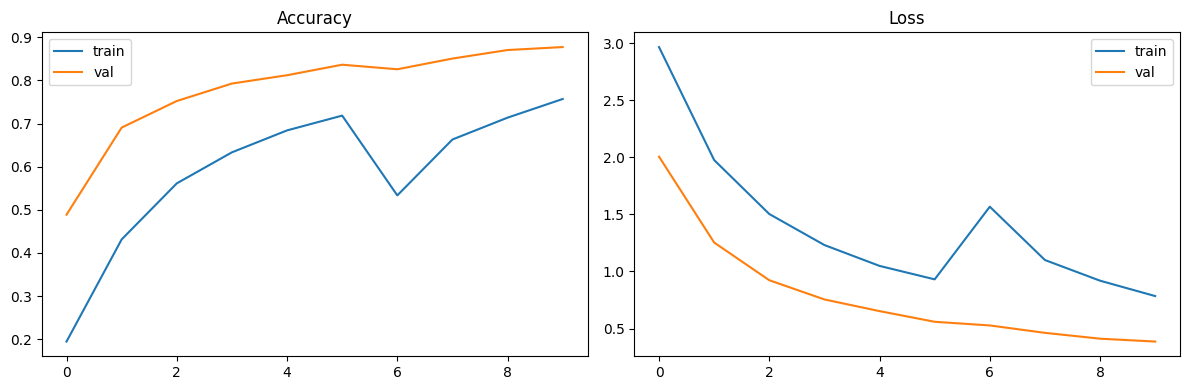

In [9]:
# [CELL 9] Plot training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].legend()

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].legend()
plt.tight_layout()
plt.show()

Test Accuracy:          0.8722
Precision (macro):      0.8835
Recall (macro):         0.8722
F1-score (macro):       0.8740
Precision (weighted):   0.8835
F1-score (weighted):    0.8740

Full classification report:

              precision    recall  f1-score   support

           A       0.93      0.92      0.93        75
           B       1.00      0.89      0.94        75
           C       0.94      0.97      0.95        75
           D       0.91      0.89      0.90        75
           E       0.86      0.85      0.86        75
           F       1.00      0.84      0.91        75
           G       0.95      0.83      0.89        75
           H       0.90      1.00      0.95        75
           I       0.94      0.81      0.87        75
           J       0.85      0.92      0.88        75
           K       0.70      0.85      0.77        75
           L       0.99      0.91      0.94        75
           M       0.86      0.84      0.85        75
           N       0.85    

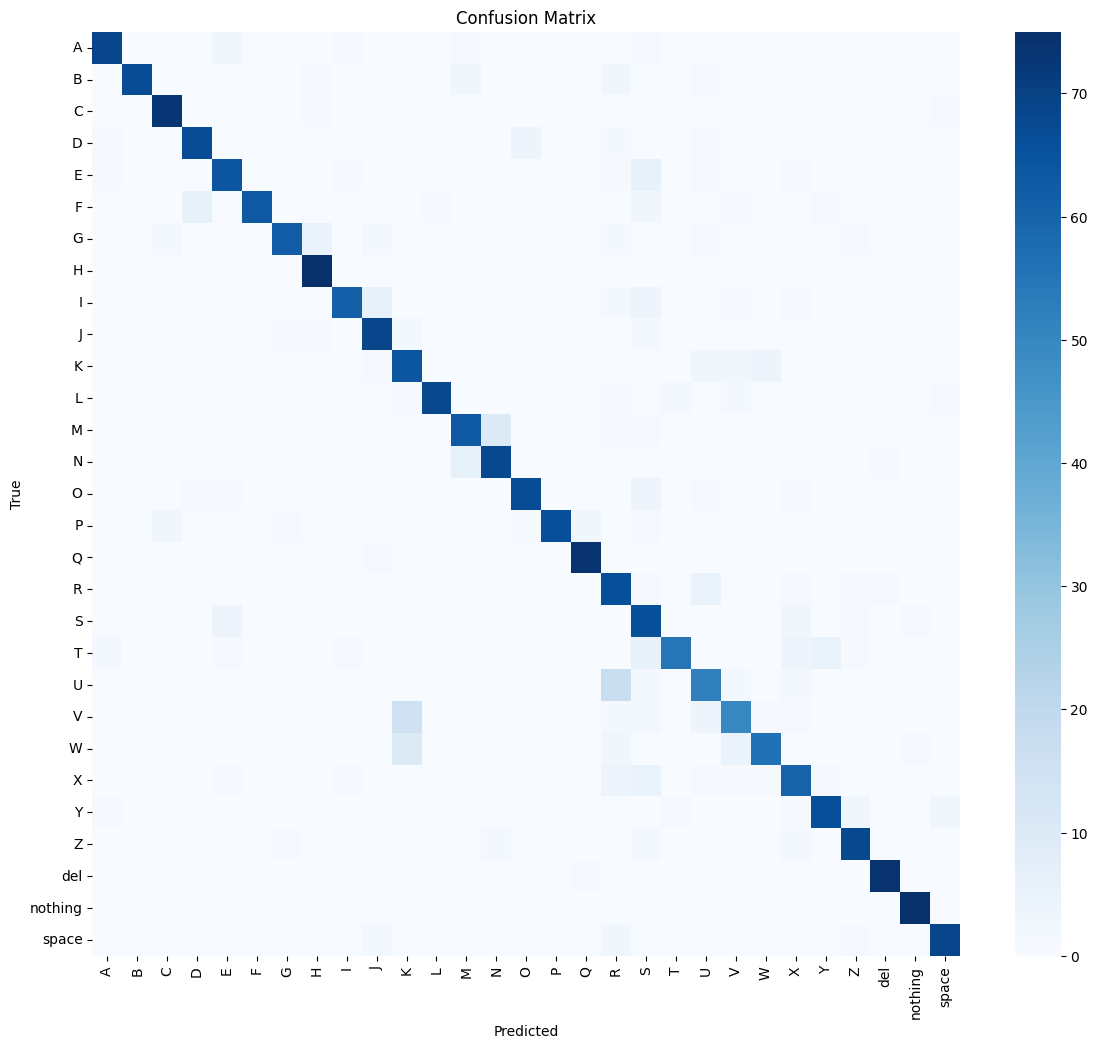

In [10]:
# [CELL 10] Evaluate on held-out test set — accuracy, precision, recall, F1, confusion matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns

y_true = []
y_pred = []

for imgs, lbls in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(lbls.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test Accuracy:          {acc:.4f}")
print(f"Precision (macro):      {prec_macro:.4f}")
print(f"Recall (macro):         {rec_macro:.4f}")
print(f"F1-score (macro):       {f1_macro:.4f}")
print(f"Precision (weighted):   {prec_weighted:.4f}")
print(f"F1-score (weighted):    {f1_weighted:.4f}")
print("\nFull classification report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

In [11]:
# [CELL 11] Save model + class mapping to Google Drive
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/asl_alphabet_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f"{SAVE_DIR}/asl_model.keras")

import json
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print(f"Saved model + class list to {SAVE_DIR}")

Mounted at /content/drive
Saved model + class list to /content/drive/MyDrive/asl_alphabet_model


In [12]:
# [CELL 11B] QUICK RECOVERY — if the runtime disconnects AFTER Cell 11 has succeeded once,
# skip all the way back here instead of retraining. Run Cell 1 (installs) + this cell only,
# then jump straight to Cell 12 (webcam). No need to redownload the dataset or retrain.
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/asl_alphabet_model"
IMG_SIZE = 96   # must match what the model was trained with

model = tf.keras.models.load_model(f"{SAVE_DIR}/asl_model.keras")
with open(f"{SAVE_DIR}/class_names.json") as f:
    CLASS_NAMES = json.load(f)

print("Model + classes reloaded from Drive -- ready to jump to Cell 12 (webcam).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model + classes reloaded from Drive -- ready to jump to Cell 12 (webcam).


Choose one ASL image from your computer


Saving L_test.jpg to L_test.jpg
Selected image: L_test.jpg

Top 3 Predictions:
L : 97.34%
space : 0.86%
T : 0.44%


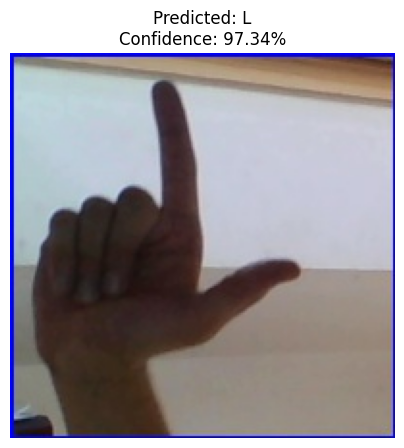


       ASL PREDICTION RESULT
Predicted Class : L
Confidence      : 97.34%


In [13]:
# [CELL 12] IMAGE UPLOAD PREDICTION (no webcam needed)
# Upload a photo of a hand sign from your device, and the model predicts the letter.

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Upload ONE image
# -------------------------------
print("Choose one ASL image from your computer")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Selected image:", image_path)


# -------------------------------
# Read image
# -------------------------------
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# -------------------------------
# Resize
# -------------------------------
img_resized = cv2.resize(
    img_rgb,
    (IMG_SIZE, IMG_SIZE)
)


# -------------------------------
# Normalize
# -------------------------------
img_resized = img_resized / 255.0


# -------------------------------
# Add batch dimension
# -------------------------------
img_batch = np.expand_dims(
    img_resized,
    axis=0
)


# -------------------------------
# Predict
# -------------------------------
preds = model.predict(
    img_batch,
    verbose=0
)[0]

top_idx = np.argmax(preds)

predicted_class = CLASS_NAMES[top_idx]

confidence = preds[top_idx]


# -------------------------------
# Top 3 predictions
# -------------------------------
top3_idx = np.argsort(preds)[-3:][::-1]

print("\nTop 3 Predictions:")

for i in top3_idx:
    print(
        f"{CLASS_NAMES[i]} : "
        f"{preds[i] * 100:.2f}%"
    )


# -------------------------------
# Display result
# -------------------------------
plt.figure(figsize=(5, 5))

plt.imshow(img_rgb)

plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()


# -------------------------------
# Final result
# -------------------------------
print("\n" + "=" * 40)
print("       ASL PREDICTION RESULT")
print("=" * 40)
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence * 100:.2f}%")
print("=" * 40)

In [14]:
# [CELL 13] Optional: upload + predict multiple images in one run
def batch_predict_uploads(model, class_names, img_size=IMG_SIZE):
    print("Choose multiple image files to upload:")
    uploaded_batch = files.upload()
    results = []
    for fname in uploaded_batch.keys():
        img_b = cv2.imread(fname)
        img_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
        img_b_resized = cv2.resize(img_b, (img_size, img_size)) / 255.0
        img_b_batch = np.expand_dims(img_b_resized, axis=0)

        preds_b = model.predict(img_b_batch, verbose=0)[0]
        top_idx_b = np.argmax(preds_b)
        letter = class_names[top_idx_b]
        conf = preds_b[top_idx_b]

        print(f"\n--- {fname} -> Predicted: {letter} ({conf*100:.1f}%) ---")
        plt.figure(figsize=(4, 4))
        plt.imshow(img_b)
        plt.title(f"{letter} ({conf*100:.1f}%)")
        plt.axis("off")
        plt.show()

        results.append((letter, conf))
    print("\nSequence predicted:", ''.join([r[0] for r in results]))
    return results

# batch_predict_uploads(model, CLASS_NAMES)